<a href="https://colab.research.google.com/github/Pornphankub/BSC_DPDM2025/blob/main/Group7_Random_forest_Regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 7 Mahamood

Slide : https://www.canva.com/design/DAHDnt_fSps/6HPogCGAfgjNb_FwoA-C6w/view?utm_content=DAHDnt_fSps&utm_campaign=designshare&utm_medium=link2&utm_source=uniquelinks&utlId=h6a73d2587b


**Model**

LSTM : https://colab.research.google.com/drive/1JzxHCgoQBUGWQ4h6LOHZJRPtWrbXQycs?usp=sharing

RadiusNeighborsRegressor : https://colab.research.google.com/drive/1VBiGI0lXPf6oRLRKh-SzzcLdzv9oU3fE?usp=sharing

regressorchain : https://colab.research.google.com/drive/1TPDUZTqYxR0pbsBvLkiAxC8AM_guStrl?usp=sharing



In [1]:
import os
import pandas as pd
import numpy as np
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
import random
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
from tqdm import tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Hyperparameters

In [3]:
# RF Hyperparameters
window_size = 12   # ใช้กับ lagged rainfall
horizon = 12
cluster = 6
k_fold_num = 2
n_estimators = 100   # จำนวนต้นไม้
random_state = 10

## Load dataset

In [4]:
X_index = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Y_variable(Rainfall).csv')
# Convert 'DATE' column in Y_df to datetime objects if it's not already
X_index['DATE'] = pd.to_datetime(X_index['DATE'])

# Format the dates in Y_df as 'YYYY-MM-01'
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')

node = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Node_table_TMD.csv')

path_feature = os.path.join("/content/drive/MyDrive/KKU_Workshop3/lookup_table_reanalysis_v5.csv")
feature = pd.read_csv(path_feature, header= "infer")

In [5]:
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

Y_rainfall_clean = Y_rainfall.copy()
#num_feature = len(feature[feature['Cluster']==cluster])

In [6]:
def apply_time_lag(df, column_name, lag):
    # Create a new column name with the lag suffix
    new_column_name = f"{column_name}_lag{lag}"

    # Shift the column values by the specified lag
    df[new_column_name] = df[column_name].shift(lag)

    return df

# Define the time lags for each climate index

time_lags = {

    'MEIV2': [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE': [1],
    'PDO': [1, 2],
    'ONI': [1, 2],
    'DMI': [1, 2],
    'BSISO1': [1],
    'BSISO1-Phase': [1],
    'SWM': [1],

}

# Apply time lags to each specified column in df_merge_type
for column, lag in time_lags.items():
      if column in X_index.columns:
            for lag_item in lag:
                X_index = apply_time_lag(X_index, column, lag_item)
      else:
        print(f"Warning: Column '{column}' not found in df_merge_type. Skipping.")


Data cleansing

In [7]:
HQ_date_get_month_df  =  Y_rainfall.copy()
Y_rainfall_clean =  Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    # Filter the data for the current year
    HQ_data = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]

    # Average rainfall
    av_r = HQ_data.iloc[:, 1:].median()

    # Create a dictionary to hold the data for this year
    month_dict = {'MONTH': month}
    month_dict.update(av_r)

    # Append the data for this year to the list
    month_avg_list.append(month_dict)

HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if(np.isnan(Y_rainfall_clean.iloc[j, i])):
             Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j]-1, i]

In [8]:
HQ_month_avg

,MONTH,300201,300202,303201,303301,310201,327202,327301,327501,328201,...,566202,567201,568301,568401,568501,568502,570201,580201,581301,583201
0,1,0.20,0.00,2.10,1.20,1.50,13.90,0.00,0.000,0.10,...,38.15,25.80,53.20,28.10,67.30,38.90,16.90,32.95,90.70,102.20
1,2,0.00,0.00,1.20,0.80,0.10,0.00,0.00,0.000,1.30,...,14.80,12.00,15.70,2.50,20.50,9.00,15.85,14.50,17.30,41.60
2,3,2.00,0.00,13.70,13.70,13.50,18.45,4.00,7.500,12.30,...,76.00,45.80,25.60,41.80,26.10,35.70,97.00,28.10,71.30,48.10
3,4,42.25,32.40,84.30,86.75,82.55,87.20,46.10,39.550,59.60,...,128.50,128.50,85.35,117.70,69.70,97.25,204.35,68.00,102.50,54.45
4,5,159.45,160.80,206.65,191.40,180.30,226.70,163.35,144.500,151.55,...,206.90,219.65,169.60,91.15,115.75,150.00,231.10,132.20,193.80,134.05
5,6,170.60,176.95,179.15,186.80,102.05,214.30,117.95,112.645,108.85,...,199.40,203.70,114.50,97.25,95.30,90.80,188.30,102.60,137.70,128.60
6,7,207.35,194.45,300.95,304.30,131.65,279.80,148.05,136.400,127.00,...,248.40,249.75,102.15,71.85,90.50,91.45,208.40,124.30,141.70,138.20
7,8,250.40,216.40,379.70,307.90,193.30,349.70,192.60,210.100,193.10,...,244.20,271.40,136.30,80.95,106.40,114.45,268.70,130.45,169.45,152.70
8,9,188.30,186.60,265.90,250.05,201.40,336.90,164.20,201.500,197.20,...,274.15,284.80,154.40,148.50,122.10,131.00,320.40,148.10,158.90,172.75
9,10,98.10,109.00,131.30,111.70,127.35,276.20,78.80,129.850,100.35,...,283.00,289.65,230.45,188.65,253.30,211.70,343.90,202.50,242.25,248.90


In [9]:
Y_rainfall_clean['DATE'].max()

'2025-03-01'

In [10]:
start_training_date = '1982-01-01'

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01
Maximum date possible :  2025-03-01 00:00:00


In [11]:
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01 00:00:00
Maximum date possible :  2025-03-01 00:00:00


In [12]:
#Count null value of each indexs
print("Number of index columns which contain null value : ",len(X_index_interval_date.isnull().sum()[X_index_interval_date.isnull().sum()>0]), sep="")
print("Number of rainfall station which contain null value : ",len(Y_rainfall_interval_date.isnull().sum()[Y_rainfall_interval_date.isnull().sum()>0]), sep="")

Number of index columns which contain null value : 0
Number of rainfall station which contain null value : 0


# Convert DATE columns to index columns

In [13]:
def convert_columns_to_index_columns(df,col_name):
    df.loc[:,col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

- independend variable dataframe

In [14]:
X_index_df_ready = convert_columns_to_index_columns(X_index_interval_date, 'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

In [15]:
print("nrow of X : {}".format(X_index_df_ready.shape[0]))
print("nrow of Y : {}".format(X_index_df_ready.shape[0]))

nrow of X : 519
nrow of Y : 519


## Standardize

In [16]:

#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()

X_normalize_data = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()

Y_normalize_data = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

In [17]:

# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'wb') as file:
    pickle.dump(scaler_Y, file)
# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_X.pkl', 'wb') as file:
    pickle.dump(scaler_X, file)


# Load the scaler for inference
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'rb') as file:
    scaler_Y = pickle.load(file)

## Summarises all climate index

In [18]:
#Get date range from original files because after normalization index will reset
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  24
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1'],
      dtype='object')


## Add cos sin function to X

### Combine static feature

In [19]:
X_index_normalized_df['Month_sin'] = np.sin(2 * np.pi * X_index_normalized_df.index.month / 12)
X_index_normalized_df['Month_cos'] = np.cos(2 * np.pi * X_index_normalized_df.index.month / 12)

In [20]:
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
  #print(code_st)

  #print(static_value)
  eindices_df = X_index_normalized_df.copy()



  eindices_df[code_st] = Y_rainfall_normalized_df[code_st]

  list_table.append(eindices_df)

In [21]:
n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  26
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1', 'Month_sin', 'Month_cos'],
      dtype='object')


## Split dataframe to add static feature

### Import meta data

### Add new date and latitude-longitude format columns

## Split training and testing

### Define start and end date of each interval

## Train Fold 1 = 2018-2020, Val = 2018-2020, Test = 2019 - 2021

## Train Fold 2 = 2018-2022, Val = 2021-2023, Test = 1/2022 - 12/2024

## Train-Test interval

In [22]:
#Train interval

start_interval_train1 =  pd.to_datetime(min(Y_rainfall_normalized_df.index))
#maximum_interval_train = max(Y_rainfall_normalized_df.index[0:-6])


end_interval_train1 = start_interval_train1 + relativedelta(months=37*12+11)


#Test1 interval
start_interval_val1 = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1 =  start_interval_train1 + relativedelta(months=38*12+11)



#Test1 interval
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1 = start_interval_train1 + relativedelta(months=39*12+11)
#end_interval_test = start_interval_test + relativedelta(months=backward_months+17)
#Display
print("############################################################")
print("TRAINING Fold 1")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train1)

print("############################################################")
print("VALIDATION Fold 1")
print('Start interval date of testing set: ', start_interval_val1)
print('End interval date of testing set :', end_interval_val1)
print("############################################################")



print("############################################################")
print("TESTING Fold 1")
print('Start interval date of testing set: ', start_interval_test1)
print('End interval date of testing set :', end_interval_test1)
print("############################################################")
#if cluster in [4 ,5,6,7, 8,9 ,10,11,12]:
#    start_interval_train1 = start_interval_val1 +  relativedelta(months=1)

#    end_interval_train2 = start_interval_train1 +  relativedelta(months=4*12+12)


    #Train interval
#    start_interval_val2 = start_interval_train1 +  relativedelta(months=3*12-1)
#    end_interval_val2 = start_interval_train1 +  relativedelta(months=5*12+10)



    #Test2 interval
#    start_interval_test2 = start_interval_train1 +  relativedelta(months=3*12+9)
#    end_interval_test2 = start_interval_train1 +  relativedelta(months=6*12+11-3)

#else:
start_interval_train1 = start_interval_train1

end_interval_train2 = start_interval_train1 + relativedelta(months=40*12)


    #Train interval
start_interval_val2 = start_interval_train1  + relativedelta(months=39*12)
end_interval_val2 = start_interval_train1 + relativedelta(months=41*12+11)



    #Test2 interval
start_interval_test2 = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2 = start_interval_train1 + relativedelta(months=42*12+11)


#Display
print("############################################################")
print("TRAINING Fold 2")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train2)

print("############################################################")
print("VALIDATION Fold 2")
print('Start interval date of testing set: ', start_interval_val2)
print('End interval date of testing set :', end_interval_val2)
print("############################################################")



print("############################################################")
print("TESTING Fold 2")
print('Start interval date of testing set: ', start_interval_test2)
print('End interval date of testing set :', end_interval_test2)
print("############################################################")

# Train Fold 1 = 1982-2019, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 1982-2022, Val = 2021-2023, Test = 2022 - 2024

############################################################
TRAINING Fold 1
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2019-12-01 00:00:00
############################################################
VALIDATION Fold 1
Start interval date of testing set:  2018-01-01 00:00:00
End interval date of testing set : 2020-12-01 00:00:00
############################################################
############################################################
TESTING Fold 1
Start interval date of testing set:  2019-01-01 00:00:00
End interval date of testing set : 2021-12-01 00:00:00
############################################################
############################################################
TRAINING Fold 2
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2022-01-01 00:00:00
############################################################
VALIDATION Fold 2
Start interval date of testing set:  2

**Reasoning**:
The date intervals have been updated, so I need to re-split the data into training, validation, and testing sets according to the new intervals defined in the previous step.



In [23]:
Train_df_list1, Val_df_list1, Test_df_list1,Train_df_list2,  Val_df_list2 ,Test_df_list2 = [], [],[],[],[],[]
for i_table in range(len(list_table)):
  Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
  Val_df_list1.append(list_table[i_table][start_interval_val1:end_interval_val1])
  Test_df_list1.append(list_table[i_table][start_interval_test1:end_interval_test1])
  Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
  Val_df_list2.append(list_table[i_table][start_interval_val2:end_interval_val2])
  Test_df_list2.append(list_table[i_table][start_interval_test2:end_interval_test2])

fold =[]
fold.append([Train_df_list1,Test_df_list1,Val_df_list1])
fold.append([Train_df_list2,Test_df_list2,Val_df_list2])

**Reasoning**:
The data has been re-split with the updated date intervals, so now I need to prepare the data for the Random Forest model and then re-train and evaluate the model, including visualizing its predictions.



# Prepare data for Random forest Regressor

In [24]:
def prepare_data_for_rf(df_single_station, n_climate_features, window_size, horizon, include_lagged_rainfall=True):
    X_rf, y_rf = [], []

    # แยกคุณลักษณะด้านภูมิอากาศ/คงที่ และข้อมูลปริมาณน้ำฝน
    climate_features_df = df_single_station.iloc[:, :n_climate_features]
    rainfall_series = df_single_station.iloc[:, n_climate_features] # คอลัมน์ปริมาณน้ำฝนสำหรับสถานีนี้

    # สร้างตัวอย่างข้อมูล
    # เริ่มต้นจาก window_size เพื่อให้แน่ใจว่ามีข้อมูลปริมาณน้ำฝนย้อนหลังเพียงพอ
    # สิ้นสุดที่ len(df_single_station) - horizon เพื่อให้แน่ใจว่ามีข้อมูลอนาคตสำหรับค่าเป้าหมายเพียงพอ
    # ปรับ `window_size` ในลูปให้สอดคล้องกับการใช้งาน เพื่อให้แน่ใจว่ามีข้อมูลสำหรับ `i-1` และ `i + horizon -1`
    start_idx = 1 if not include_lagged_rainfall else window_size
    for i in range(start_idx, len(df_single_station) - horizon + 1):
        # คุณลักษณะสำหรับตัวอย่างปัจจุบัน (ทำนายปริมาณน้ำฝนที่เวลา `i + horizon - 1`):
        # 1. ดัชนีภูมิอากาศที่เวลา `i-1` (ข้อมูลภูมิอากาศที่ทราบล่าสุดก่อนจุดทำนาย `i+horizon-1`)
        current_climate_features = climate_features_df.iloc[i-1].values

        combined_features = current_climate_features

        if include_lagged_rainfall:
            # 2. ค่าปริมาณน้ำฝนที่ล่าช้า (จาก `i - window_size` ถึง `i - 1`)
            lagged_rainfall_features = rainfall_series.iloc[i-window_size : i].values
            # รวมคุณลักษณะทั้งหมดสำหรับตัวอย่างปัจจุบัน
            combined_features = np.concatenate((current_climate_features, lagged_rainfall_features))

        X_rf.append(combined_features)

        # ค่าเป้าหมายสำหรับตัวอย่างปัจจุบัน: ปริมาณน้ำฝนที่ `i + horizon - 1`
        target_rainfall = rainfall_series.iloc[i + horizon - 1]
        y_rf.append(target_rainfall)

    return np.array(X_rf), np.array(y_rf)

## กำหนด cluster_station

In [25]:
# กำหนด cluster_station
cluster_station = []
for index in range(0, len(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index] == 1 and node['cluster'].iloc[index] == cluster):
        cluster_station.append(index)

print(f"จำนวนสถานีใน Cluster {cluster}: {len(cluster_station)} สถานี")
print(f"Index ของสถานี: {cluster_station}")

จำนวนสถานีใน Cluster 6: 7 สถานี
Index ของสถานี: [17, 30, 31, 34, 35, 36, 37]


In [26]:
for index in range(len(cluster_station)):
    print(node['Node'].iloc[cluster_station[index]])

351201
376201
376202
376401
378201
379201
379401


## select feature

In [27]:
def select_feature_f(list_df,position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:,position_feature_index]
    return list_df

In [28]:
selected_index = []
feature_cluster = feature[feature['Cluster'] == cluster]
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if((feature_climate[i] == feature_cluster.iloc[feature_index, 1]) and
           feature_cluster.iloc[feature_index, 5] == 0):
            selected_index.append(i)
        elif(feature_cluster.iloc[feature_index, 5] != 0):
            for i_lag in range(len(feature_climate)):
                if(feature_climate[i_lag] == feature_cluster.iloc[feature_index, 1] +
                   '_lag' + str(feature_cluster.iloc[feature_index, 5])):
                    selected_index.append(i_lag)
                    break
                else:
                    continue
            break

selected_index.sort()

# กำหนด position_all_index (climate + rainfall column) by directly appending the rainfall column index
position_all_index = list(selected_index)
position_all_index.append(n_feature_climate)  # n_feature_climate holds the index of the rainfall column
position_all_index.sort()

n_feature_climate_selected = len(selected_index)

print(f"selected_index: {selected_index}")
print(f"position_all_index: {position_all_index}")
print(f"จำนวน features ที่เลือก: {n_feature_climate_selected}")
print(f"Features: {list(feature_climate[selected_index])}")

selected_index: [1, 3, 5, 8, 9, 17, 24, 25]
position_all_index: [1, 3, 5, 8, 9, 17, 24, 25, 26]
จำนวน features ที่เลือก: 8
Features: ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


In [29]:
random.seed(10)
# Initialize a list of selected indices with the climate feature indices
position_all_index = list(selected_index)
# Add the index of the rainfall column, which is n_feature_climate (26)
position_all_index.append(n_feature_climate)

# Sort the indices to maintain order if desired, although not strictly necessary for .iloc
position_all_index.sort()

# Define climate_name_list based on the selected_index (climate features only)
climate_name_list = [feature_climate[idx] for idx in selected_index]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 17, 24, 25, 26]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


In [30]:
# ทำสำเนา fold ก่อน ไม่งั้นจะแก้ไข list_table ต้นฉบับ
fold_selected = copy.deepcopy(fold)

for fold_idx in range(2):
    fold_selected[fold_idx][0] = select_feature_f(fold_selected[fold_idx][0], position_all_index)  # Train
    fold_selected[fold_idx][1] = select_feature_f(fold_selected[fold_idx][1], position_all_index)  # Test
    fold_selected[fold_idx][2] = select_feature_f(fold_selected[fold_idx][2], position_all_index)  # Val

In [31]:
for fold_idx in range(2):
    for station_idx in cluster_station:
        df_train = fold_selected[fold_idx][0][station_idx]  # ← fold_selected
        df_val   = fold_selected[fold_idx][2][station_idx]
        df_test  = fold_selected[fold_idx][1][station_idx]

        X_train, y_train = prepare_data_for_rf(
            df_train, n_feature_climate_selected,  # ← n_feature_climate_selected
            window_size, horizon)

# RandomForestRegressor Model

In [32]:
best_model = None
best_rmse = float('inf')
best_fold_idx = -1
fold_results = {}

for fold_idx in range(2):
    print(f"\n{'='*50}")
    print(f"FOLD {fold_idx + 1}")
    print(f"{'='*50}")

    X_train_all, y_train_all = [], []
    X_val_all,   y_val_all   = [], []
    X_test_all,  y_test_all  = [], []

    for station_idx in cluster_station:
        df_train = fold_selected[fold_idx][0][station_idx]  # ← fold → fold_selected
        df_val   = fold_selected[fold_idx][2][station_idx]  # ← fold → fold_selected
        df_test  = fold_selected[fold_idx][1][station_idx]  # ← fold → fold_selected

        X_train, y_train = prepare_data_for_rf(df_train, n_feature_climate_selected, window_size, horizon, include_lagged_rainfall=True)
        X_val,   y_val   = prepare_data_for_rf(df_val,   n_feature_climate_selected, window_size, horizon, include_lagged_rainfall=True)
        X_test,  y_test  = prepare_data_for_rf(df_test,  n_feature_climate_selected, window_size, horizon, include_lagged_rainfall=True)

        X_train_all.append(X_train)
        y_train_all.append(y_train)
        X_val_all.append(X_val)
        y_val_all.append(y_val)
        X_test_all.append(X_test)
        y_test_all.append(y_test)

    X_train_all = np.concatenate(X_train_all, axis=0)
    y_train_all = np.concatenate(y_train_all, axis=0)
    X_val_all   = np.concatenate(X_val_all,   axis=0)
    y_val_all   = np.concatenate(y_val_all,   axis=0)
    X_test_all  = np.concatenate(X_test_all,  axis=0)
    y_test_all  = np.concatenate(y_test_all,  axis=0)

    print(f"X_train: {X_train_all.shape}, X_val: {X_val_all.shape}, X_test: {X_test_all.shape}")

    model = RandomForestRegressor(n_estimators=100, random_state=10)
    model.fit(X_train_all, y_train_all)

    y_val_pred  = model.predict(X_val_all)
    val_rmse = np.sqrt(mean_squared_error(y_val_all, y_val_pred))
    val_mse  = mean_squared_error(y_val_all, y_val_pred)
    val_mae  = mean_absolute_error(y_val_all, y_val_pred)
    val_r2   = r2_score(y_val_all, y_val_pred)

    y_test_pred = model.predict(X_test_all)
    test_rmse = np.sqrt(mean_squared_error(y_test_all, y_test_pred))
    test_mse  = mean_squared_error(y_test_all, y_test_pred)
    test_mae  = mean_absolute_error(y_test_all, y_test_pred)
    test_r2   = r2_score(y_test_all, y_test_pred)

    print(f"Val  RMSE: {val_rmse:.4f} | MSE: {val_mse:.4f} | MAE: {val_mae:.4f} | R2: {val_r2:.4f}")
    print(f"Test RMSE: {test_rmse:.4f} | MSE: {test_mse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")

    fold_results[fold_idx] = {
        "model": model,
        "val_rmse": val_rmse, "val_mse": val_mse, "val_mae": val_mae, "val_r2": val_r2,
        "test_rmse": test_rmse, "test_mse": test_mse, "test_mae": test_mae, "test_r2": test_r2,
        "y_test": y_test_all,
        "y_test_pred": y_test_pred
    }

    # if val_rmse < best_rmse:
    #     best_rmse = val_rmse
    #     best_model = model        # ← ตรงนี้ที่กำหนด best_model
    #     best_fold_idx = fold_idx


FOLD 1
X_train: (3031, 20), X_val: (91, 20), X_test: (91, 20)
Val  RMSE: 0.6043 | MSE: 0.3652 | MAE: 0.4491 | R2: 0.5158
Test RMSE: 0.9203 | MSE: 0.8470 | MAE: 0.5592 | R2: 0.4273

FOLD 2
X_train: (3206, 20), X_val: (91, 20), X_test: (91, 20)
Val  RMSE: 0.7181 | MSE: 0.5157 | MAE: 0.4807 | R2: 0.5504
Test RMSE: 0.5549 | MSE: 0.3079 | MAE: 0.3983 | R2: 0.6299


In [33]:
print(f"n_feature_climate_selected = {n_feature_climate_selected}")
print(f"window_size = {window_size}")
print(f"features ที่คาดว่าจะได้ = {n_feature_climate_selected + window_size}")
print(f"Features ที่เลือก: {list(feature_climate[selected_index])}")

n_feature_climate_selected = 8
window_size = 12
features ที่คาดว่าจะได้ = 20
Features ที่เลือก: ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


# Perdict

In [34]:
best_fold_idx = 1
best_model = fold_results[1]['model']

print(f"✅ ใช้ Fold 2 สำหรับทำนายปี 2024")
print(f"   Test RMSE: {fold_results[1]['test_rmse']:.4f} | R2: {fold_results[1]['test_r2']:.4f}")

✅ ใช้ Fold 2 สำหรับทำนายปี 2024
   Test RMSE: 0.5549 | R2: 0.6299


X_inputs.shape: (12, 20)


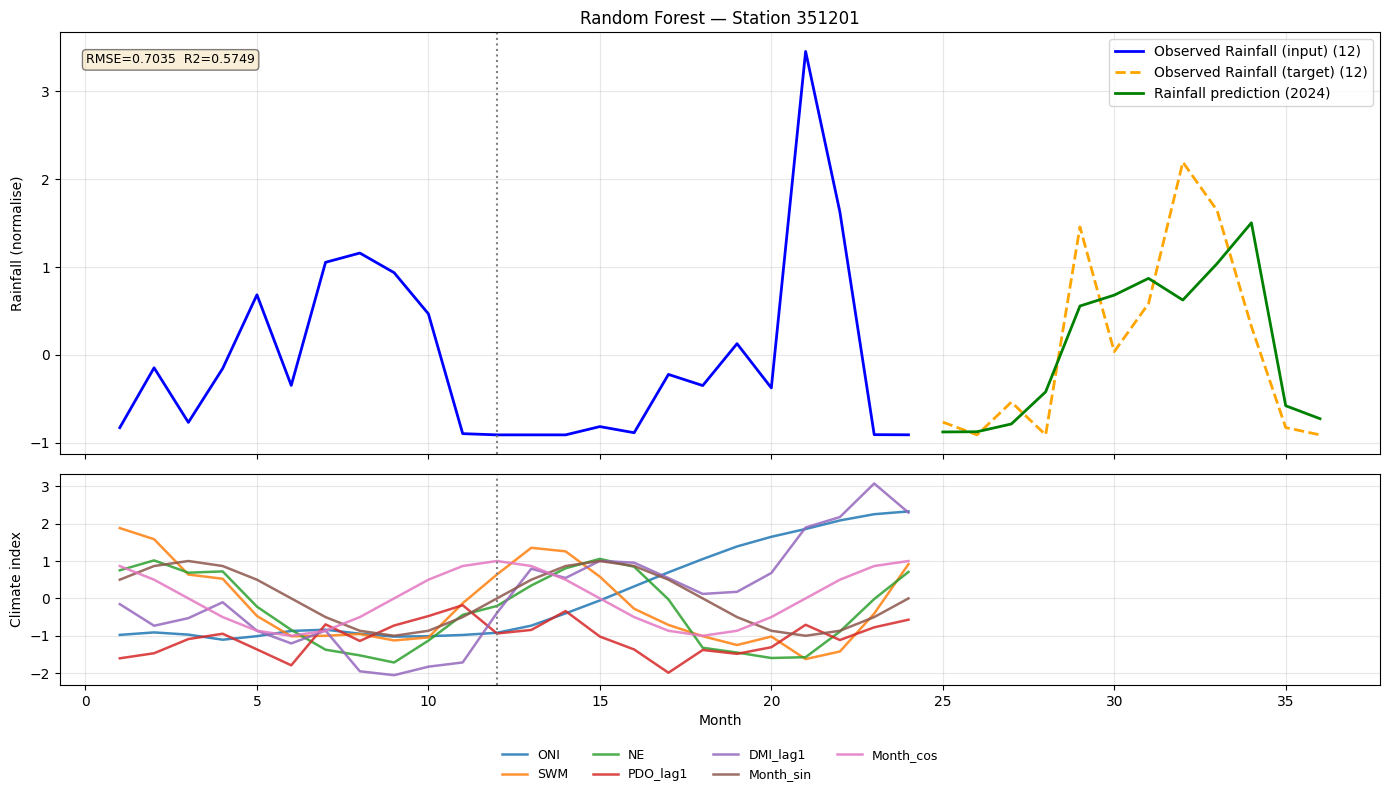

X_inputs.shape: (12, 20)


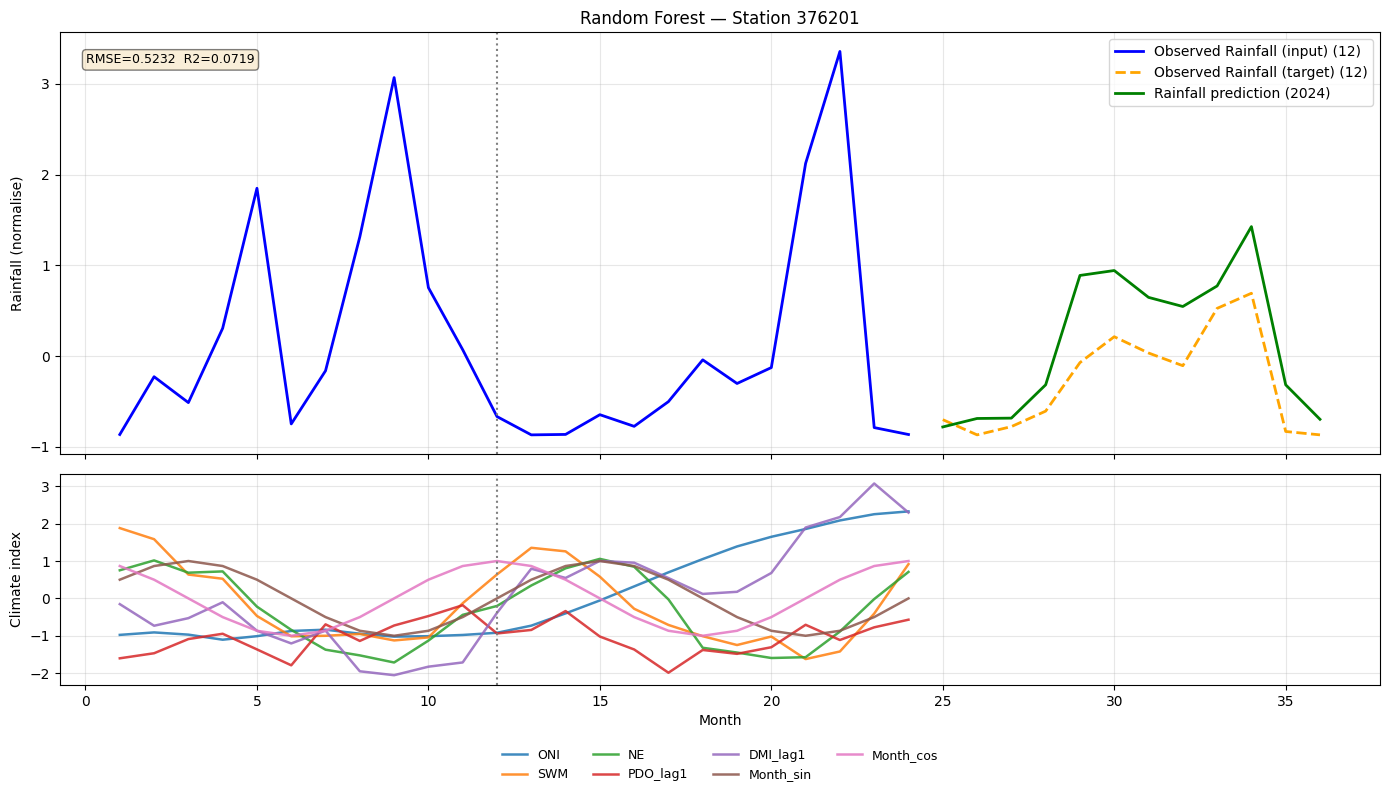

X_inputs.shape: (12, 20)


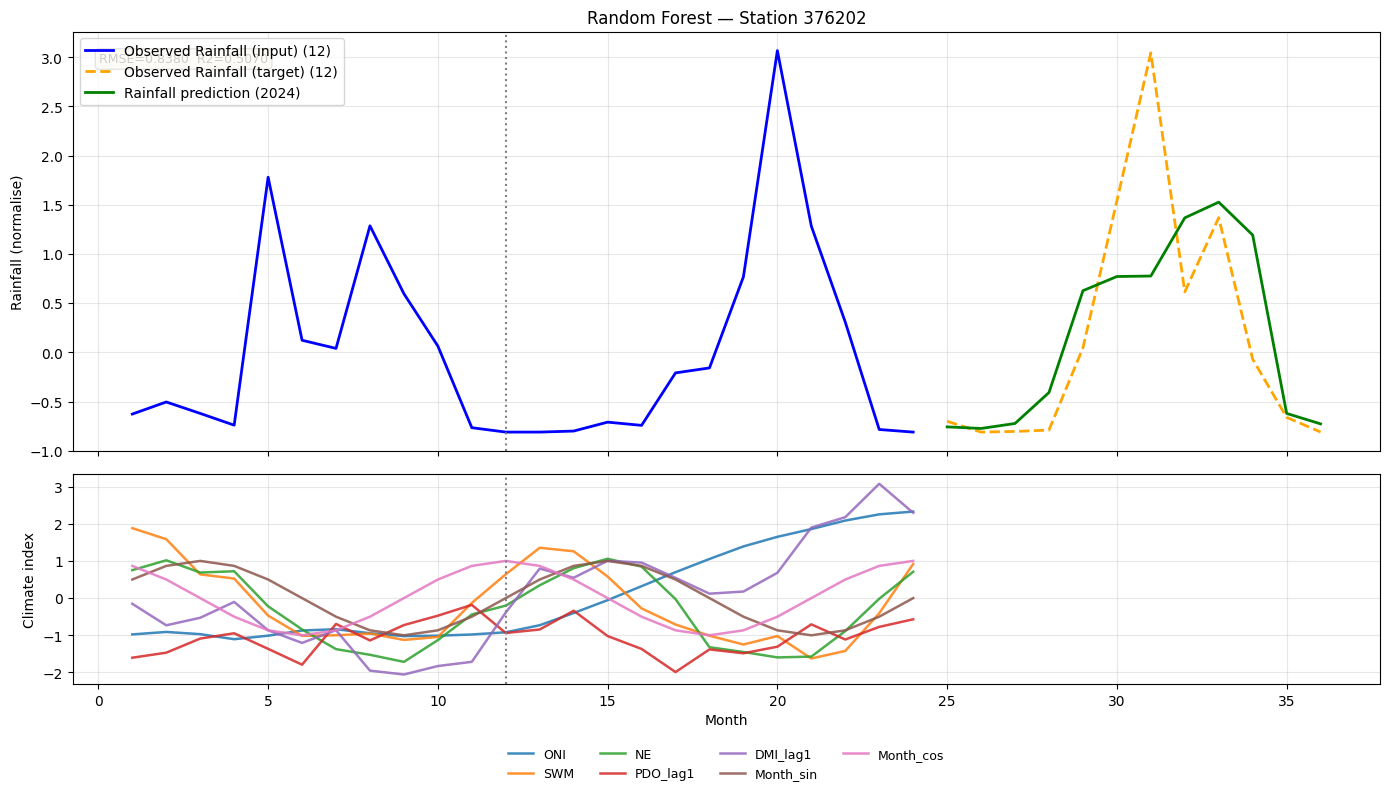

X_inputs.shape: (12, 20)


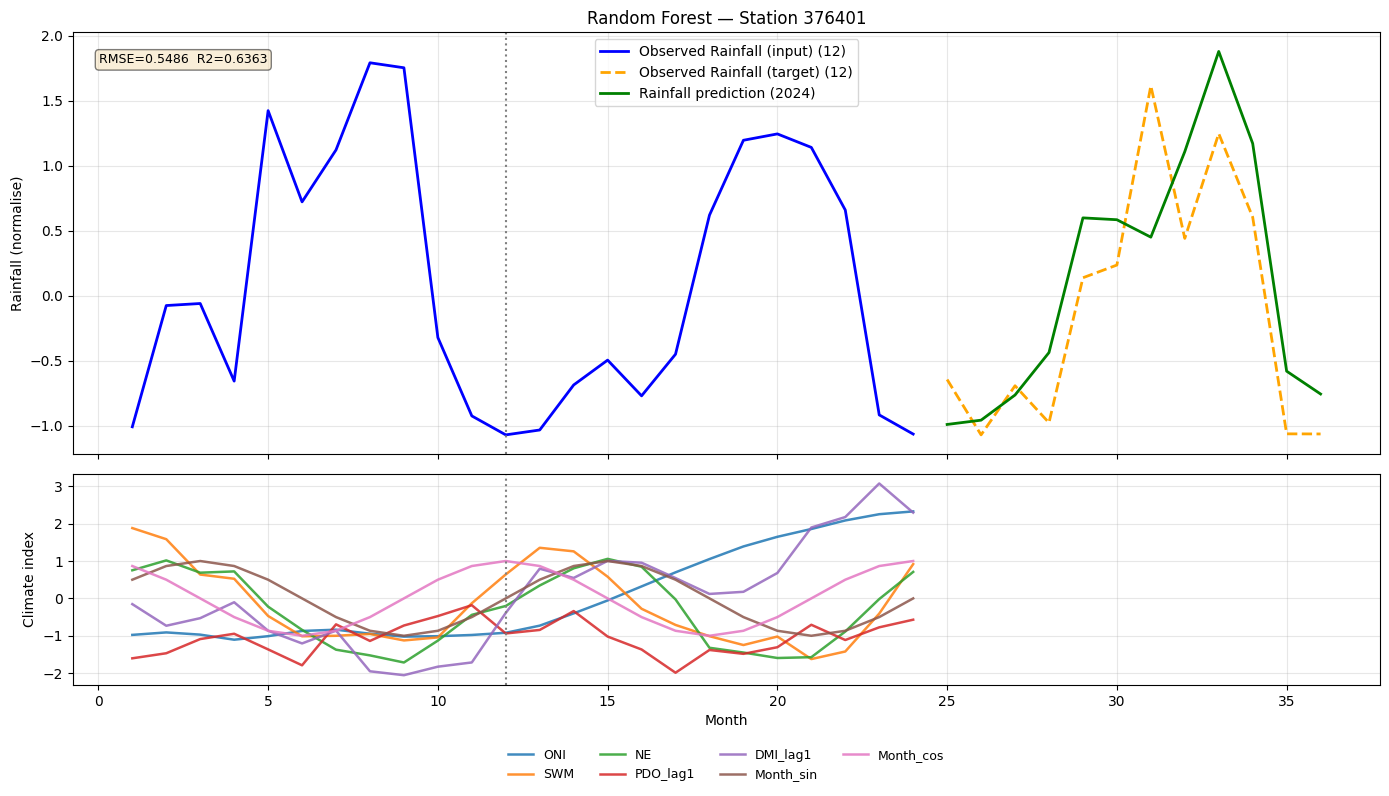

X_inputs.shape: (12, 20)


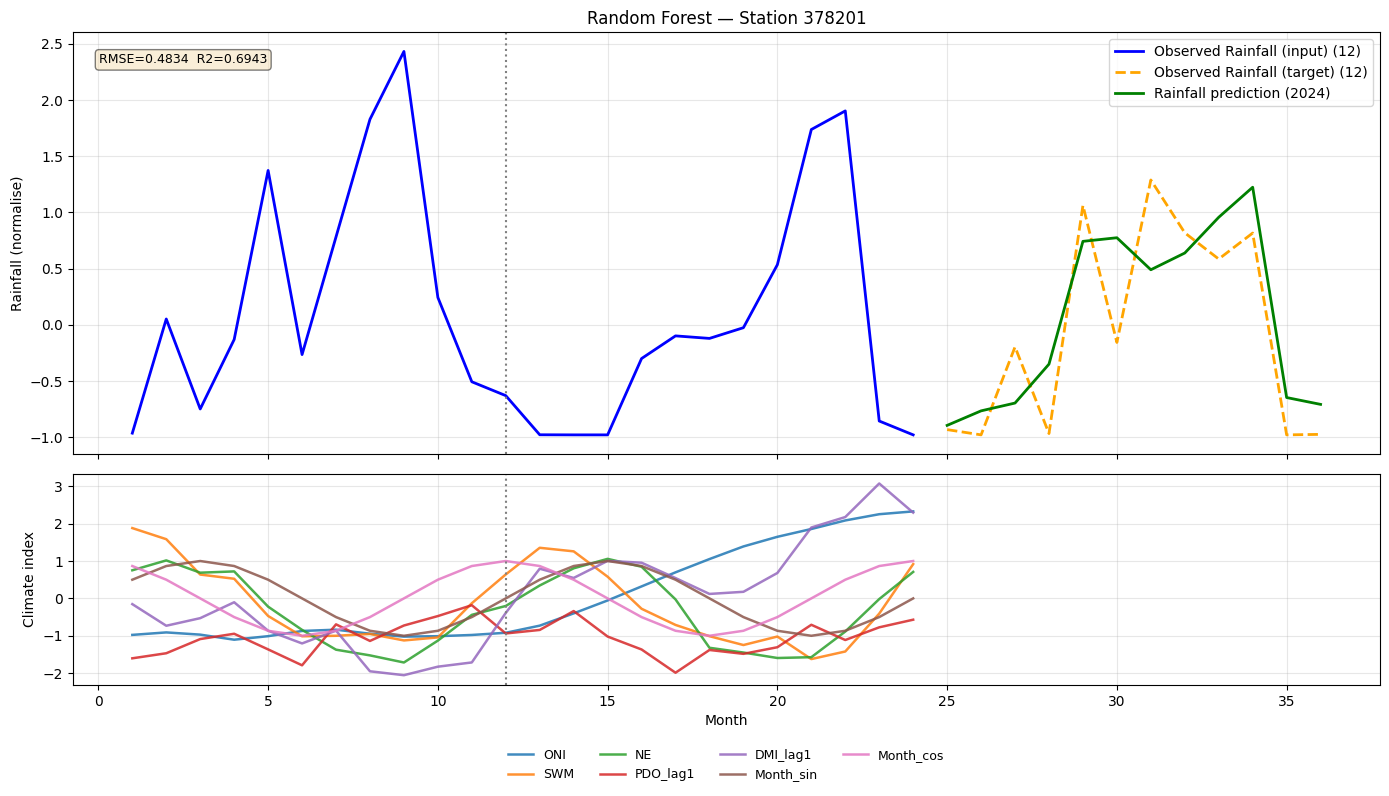

X_inputs.shape: (12, 20)


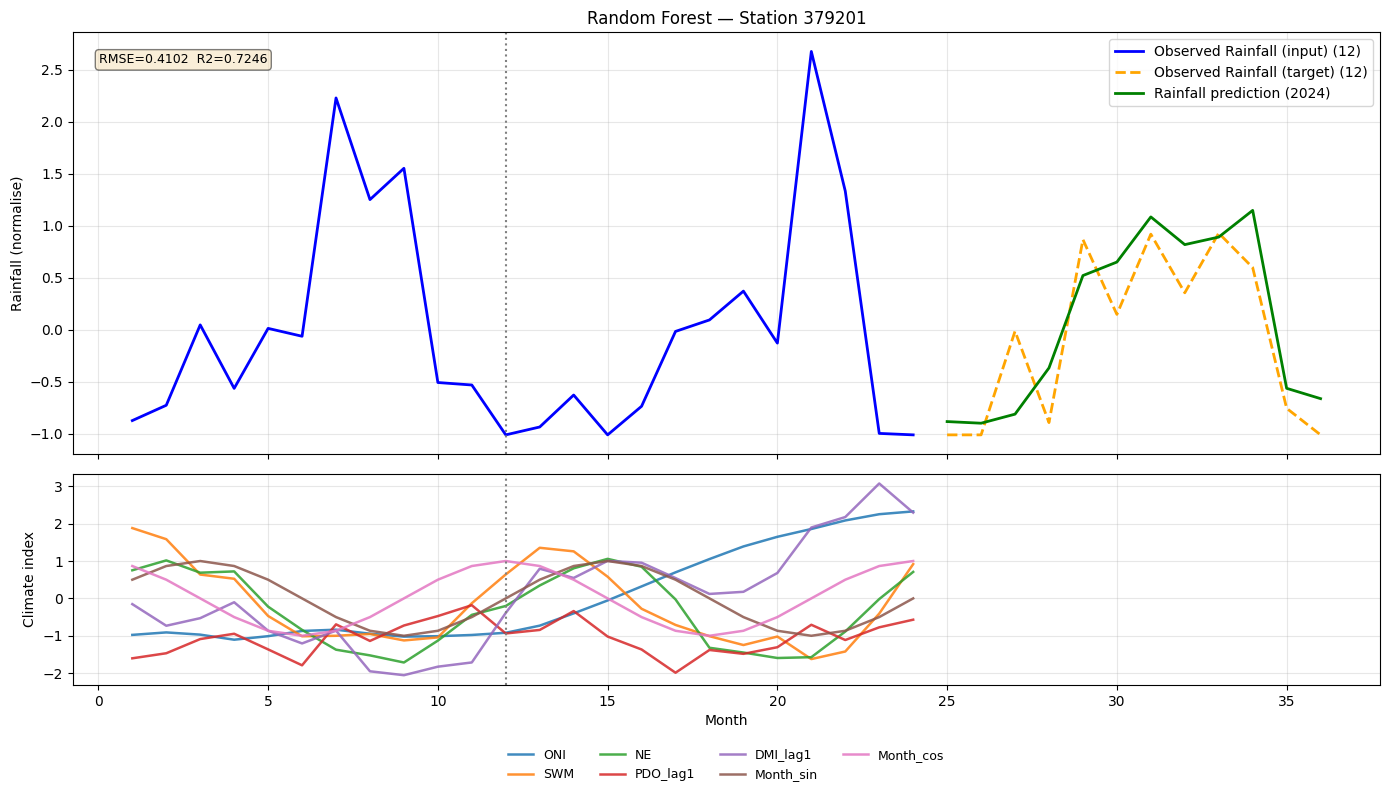

X_inputs.shape: (12, 20)


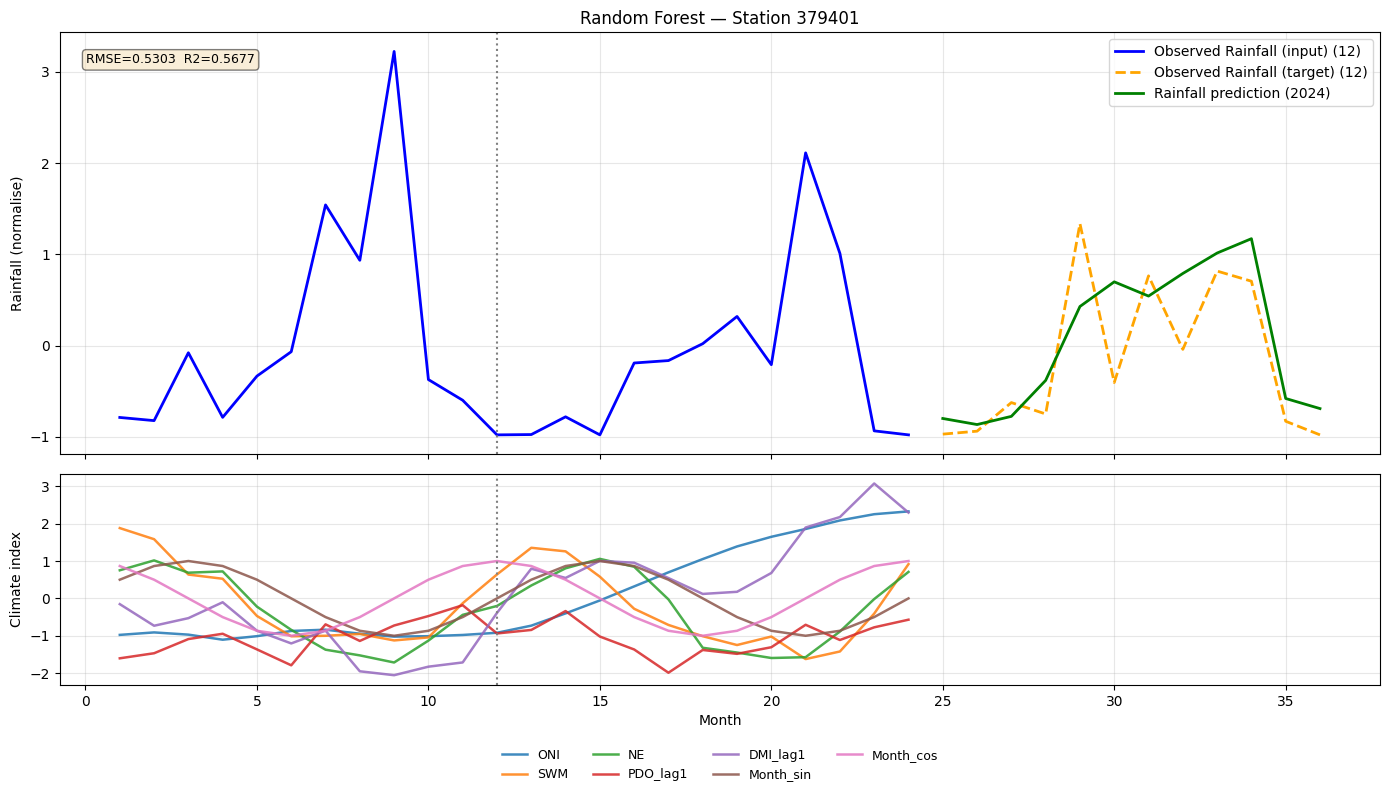

In [35]:
# กำหนดช่วงเวลา
input_start  = '2022-01-01'
input_end    = '2023-12-01'
target_start = '2024-01-01'
target_end   = '2024-12-01'

# เลือก climate features ที่จะแสดง (เลือกบางตัวให้ไม่รกเกินไป)
selected_climate_for_plot = ['ONI', 'SWM', 'NE', 'PDO_lag1', 'DMI_lag1', 'Month_sin', 'Month_cos']

for station_idx in cluster_station:
    df_full = list_table[station_idx]
    station_name = node['Node'].iloc[station_idx]

    # ดึงข้อมูล
    df_window = df_full.loc[input_start:input_end]   # 24 เดือน (window)
    df_target = df_full.loc[target_start:target_end]  # 12 เดือน (target)

    # rainfall
    # The rainfall column in df_full (which is from list_table) is at index n_feature_climate
    rain_window = df_window.iloc[:, n_feature_climate].values   # input rainfall
    rain_target = df_target.iloc[:, n_feature_climate].values   # actual 2024

    # climate index (window เท่านั้น)
    climate_window = df_window[selected_climate_for_plot].values         # (24, n_selected_for_plot)

    # ทำนาย: ใช้ Climate Index ปี 2023 + lagged rainfall เป็น input
    X_inputs_list = []
    for i in range(12):  # 12 เดือน (ม.ค.-ธ.ค. 2023)
        # Climate Index เดือน i ของปี 2023
        climate_row = df_full.loc['2023-01-01':input_end].iloc[i, selected_index].values  # (8,)

        # Lagged rainfall: 12 เดือนก่อนหน้าเดือน i ของปี 2023
        # เดือน i ของปี 2023 = index ที่ df_full
        current_pos = df_full.index.get_loc(df_full.loc['2023-01-01':input_end].index[i])
        lagged_rain = df_full.iloc[current_pos - window_size:current_pos, n_feature_climate].values  # (12,)

        combined = np.concatenate([climate_row, lagged_rain])  # (20,)
        X_inputs_list.append(combined)

    X_inputs = np.array(X_inputs_list)  # (12, 20)
    print(f"X_inputs.shape: {X_inputs.shape}")  # ควรได้ (12, 20)

    y_pred = best_model.predict(X_inputs)  # ทำนาย 12 เดือน
    # กำหนด x axis
    # ย้ายออกไปนอกลูป หรือใช้ชื่อตัวแปรอื่น
    plot_window_size = len(rain_window)   # 24 เดือนที่แสดงในกราฟ
    horizon          = len(rain_target)   # 12
    t_window = np.arange(1, plot_window_size + 1)
    t_target = np.arange(plot_window_size + 1, plot_window_size + horizon + 1)

    # ===== Plot =====
    fig, axes = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # --- (A) Rainfall ---
    axes[0].plot(t_window, rain_window,
                 label=f"Observed Rainfall (input) ({window_size})",
                 color='blue', linewidth=2)
    axes[0].plot(t_target, rain_target,
                 label=f"Observed Rainfall (target) ({horizon})",
                 color='orange', linewidth=2, linestyle='--')
    axes[0].plot(t_target, y_pred,
                 label="Rainfall prediction (2024)",
                 color='green', linewidth=2)
    axes[0].axvline(window_size, color='gray', linestyle=':')
    axes[0].set_ylabel("Rainfall (normalise)")
    axes[0].set_title(f"Random Forest — Station {station_name}")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # แสดง metric
    from sklearn.metrics import mean_squared_error, r2_score
    rmse = np.sqrt(mean_squared_error(rain_target, y_pred))
    r2   = r2_score(rain_target, y_pred)
    axes[0].text(0.02, 0.95, f"RMSE={rmse:.4f}  R2={r2:.4f}",
                 transform=axes[0].transAxes, fontsize=9,
                 verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # --- (B) Climate Index ---
    for i, name in enumerate(selected_climate_for_plot):
        # climate_window already contains only the selected_climate_for_plot features
        axes[1].plot(t_window, climate_window[:, i],
                     linewidth=1.8, alpha=0.85, label=name)
    axes[1].axvline(window_size, color='gray', linestyle=':')
    axes[1].set_ylabel("Climate index")
    axes[1].set_xlabel("Month")
    axes[1].legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.25),
        ncol=min(4, len(selected_climate_for_plot)),
        fontsize=9,
        frameon=False
    )
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()